Dataset link: https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews

In [2]:
# =========================
#  IMPORT LIBRARIES
# =========================

# Basic
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Text Processing
import re
import nltk
from nltk.corpus import stopwords

# Deep Learning
import torch
import torch.nn as nn

# Transformers (BERT)
from transformers import BertTokenizer, BertModel

# XGBoost
from xgboost import XGBClassifier

# Extra Trees
from sklearn.ensemble import ExtraTreesClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Download NLTK data (run once)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(" GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print(" GPU not available, using CPU")

print("Using device:", device)

 GPU is available!
GPU Name: Tesla T4
Using device: cuda


In [4]:
# =========================
#  LOAD DATASET
# =========================

# Replace this path with your actual dataset path
data_path = "/kaggle/input/datasets/arhamrumi/amazon-product-reviews/Reviews.csv"

df = pd.read_csv(data_path)

# Show basic info
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [6]:
# =========================
#  DROP UNWANTED COLUMNS
# =========================

# Keep only required columns
df = df[['Summary', 'Text', 'Score']]

# Check result
print("Updated Shape:", df.shape)
df.head()

Updated Shape: (568454, 3)


,Summary,Text,Score
0,Good Quality Dog Food,I have bought several of the Vitality canned d...,5
1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,1
2,"""Delight"" says it all",This is a confection that has been around a fe...,4
3,Cough Medicine,If you are looking for the secret ingredient i...,2
4,Great taffy,Great taffy at a great price. There was a wid...,5


In [7]:
df.dropna(inplace=True)
print("After removing nulls:", df.shape)

After removing nulls: (568427, 3)


In [8]:
def convert_sentiment(score):
    if score <= 2:
        return 0  # Negative
    elif score >= 4:
        return 1  # Positive
    else:
        return np.nan  # Neutral (we will remove)

df['Sentiment'] = df['Score'].apply(convert_sentiment)

In [9]:
# Remove neutral reviews
df = df.dropna(subset=['Sentiment'])

In [10]:
# Combine Summary + Text
df['Review'] = df['Summary'] + " " + df['Text']

In [11]:
# Keep only needed columns
df = df[['Review', 'Sentiment']]

In [12]:
print("Final dataset shape:", df.shape)

Final dataset shape: (525789, 2)


In [13]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Sentiment'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (420631, 2)
Test shape: (105158, 2)


In [14]:
# Save to CSV
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print(" Train and Test CSV saved successfully")

 Train and Test CSV saved successfully


In [15]:
# Load stopwords
stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [16]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [17]:
# Apply preprocessing 
print("Preprocessing training data...")
train_df['Clean_Review'] = train_df['Review'].apply(clean_text)

print("Preprocessing test data...")
test_df['Clean_Review'] = test_df['Review'].apply(clean_text)

Preprocessing training data...
Preprocessing test data...


In [18]:
# Keep final columns
train_df = train_df[['Clean_Review', 'Sentiment']]
test_df = test_df[['Clean_Review', 'Sentiment']]

# Save processed data
train_df.to_csv("train_clean.csv", index=False)
test_df.to_csv("test_clean.csv", index=False)

print(" Preprocessing completed and saved")

 Preprocessing completed and saved


In [ ]:
# Load cleaned data
train_df = pd.read_csv("train_clean.csv")
test_df = pd.read_csv("test_clean.csv")

In [20]:
# Fix NaN values
train_df = train_df.dropna(subset=['Clean_Review'])
test_df = test_df.dropna(subset=['Clean_Review'])

# Convert to string (extra safety)
train_df['Clean_Review'] = train_df['Clean_Review'].astype(str)
test_df['Clean_Review'] = test_df['Clean_Review'].astype(str)

print("After cleaning:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

After cleaning:
Train shape: (420630, 2)
Test shape: (105158, 2)


In [21]:
# =========================
#  FEATURE EXTRACTION
# =========================

from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm



# -------------------------
# TF-IDF
# -------------------------
tfidf = TfidfVectorizer(max_features=5000)

print("Fitting TF-IDF...")
X_train_tfidf = tfidf.fit_transform(train_df['Clean_Review'])
X_test_tfidf = tfidf.transform(test_df['Clean_Review'])

print("TF-IDF shape:", X_train_tfidf.shape)


# -------------------------
# BERT EMBEDDINGS
# -------------------------

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()


def get_bert_embeddings(texts, batch_size=32):
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size].tolist()
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = bert_model(**inputs)
        
        # CLS token embedding
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
    
    return np.vstack(embeddings)


#  VERY IMPORTANT: Start with smaller subset to test
sample_train = train_df.sample(20000, random_state=42)
sample_test = test_df.sample(5000, random_state=42)

print("Generating BERT embeddings (train)...")
X_train_bert = get_bert_embeddings(sample_train['Clean_Review'])

print("Generating BERT embeddings (test)...")
X_test_bert = get_bert_embeddings(sample_test['Clean_Review'])

print("BERT shape:", X_train_bert.shape)

Fitting TF-IDF...


TF-IDF shape: (420630, 5000)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Generating BERT embeddings (train)...


100%|██████████| 625/625 [02:02<00:00,  5.11it/s]


Generating BERT embeddings (test)...


100%|██████████| 157/157 [00:33<00:00,  4.67it/s]


BERT shape: (20000, 768)


In [22]:
# Align TF-IDF with sampled data

X_train_tfidf_sample = tfidf.transform(sample_train['Clean_Review'])
X_test_tfidf_sample = tfidf.transform(sample_test['Clean_Review'])

print("TF-IDF Sample shape:", X_train_tfidf_sample.shape)

TF-IDF Sample shape: (20000, 5000)


In [23]:
# =========================
# COMBINE FEATURES
# =========================

from scipy.sparse import hstack

# Convert TF-IDF to array (needed for combining)
X_train_tfidf_dense = X_train_tfidf_sample.toarray()
X_test_tfidf_dense = X_test_tfidf_sample.toarray()

# Combine TF-IDF + BERT
X_train_combined = np.hstack((X_train_tfidf_dense, X_train_bert))
X_test_combined = np.hstack((X_test_tfidf_dense, X_test_bert))

print("Combined train shape:", X_train_combined.shape)
print("Combined test shape:", X_test_combined.shape)

Combined train shape: (20000, 5768)
Combined test shape: (5000, 5768)


In [24]:
# =========================
# PREPARE LABELS
# =========================

y_train = sample_train['Sentiment'].values
y_test = sample_test['Sentiment'].values

print("y_train shape:", y_train.shape)

y_train shape: (20000,)


In [25]:
# =========================
# CNN MODEL
# =========================

class CNNFeatureExtractor(nn.Module):
    def __init__(self, input_dim):
        super(CNNFeatureExtractor, self).__init__()
        
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        
        self.fc = nn.Linear((input_dim // 2) * 64, 128)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        
        x = self.relu(self.conv2(x))
        
        x = x.view(x.size(0), -1)
        
        x = self.fc(x)
        x = self.dropout(x)
        
        return x

In [26]:
# =========================
# INITIALIZE MODEL
# =========================

input_dim = X_train_combined.shape[1]

cnn_model = CNNFeatureExtractor(input_dim).to(device)

print("CNN Model initialized with input dim:", input_dim)

CNN Model initialized with input dim: 5768


In [27]:
# =========================
# . TRAIN CNN
# =========================

from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_tensor = torch.tensor(X_train_combined, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_combined, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# Training loop
epochs = 5

cnn_model.train()

for epoch in range(epochs):
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = cnn_model(X_batch)
        
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")

Epoch [1/5], Loss: 509.1008
Epoch [2/5], Loss: 440.5672
Epoch [3/5], Loss: 431.1359
Epoch [4/5], Loss: 418.4912
Epoch [5/5], Loss: 400.7012


In [28]:
# =========================
# EXTRACT CNN FEATURES
# =========================

cnn_model.eval()

def extract_features(model, X_tensor):
    features = []
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), 64):
            batch = X_tensor[i:i+64].to(device)
            output = model(batch)
            features.append(output.cpu().numpy())
    
    return np.vstack(features)


print("Extracting train features...")
X_train_cnn = extract_features(cnn_model, X_train_tensor)

print("Extracting test features...")
X_test_cnn = extract_features(cnn_model, X_test_tensor)

print("CNN Feature shape:", X_train_cnn.shape)

Extracting train features...
Extracting test features...
CNN Feature shape: (20000, 128)


In [29]:
# =========================
# TRAIN ENSEMBLE MODELS
# =========================

# Extra Trees
extra_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
extra_model.fit(X_train_cnn, y_train)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_cnn, y_train)

print(" Ensemble models trained")

 Ensemble models trained


In [30]:
# =========================
# STACKING (AVERAGE)
# =========================

extra_preds = extra_model.predict_proba(X_test_cnn)
xgb_preds = xgb_model.predict_proba(X_test_cnn)

# Average probabilities
final_preds_proba = (extra_preds + xgb_preds) / 2

# Convert to class
final_preds = np.argmax(final_preds_proba, axis=1)

Accuracy: 0.9188

Classification Report:

              precision    recall  f1-score   support

         0.0       0.79      0.65      0.71       773
         1.0       0.94      0.97      0.95      4227

    accuracy                           0.92      5000
   macro avg       0.86      0.81      0.83      5000
weighted avg       0.91      0.92      0.92      5000



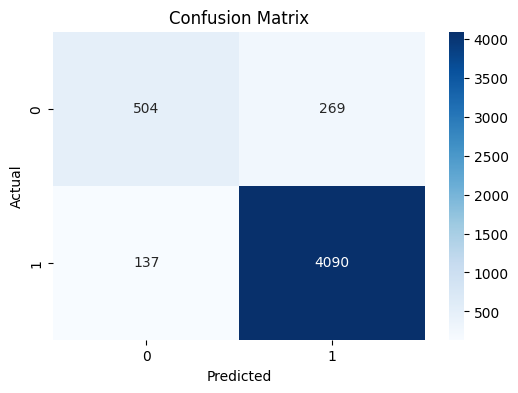

ROC-AUC Score: 0.9358445721476948


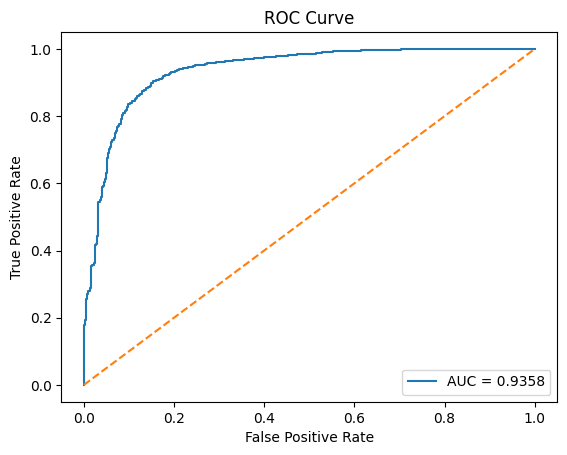

In [31]:


# Accuracy
acc = accuracy_score(y_test, final_preds)
print("Accuracy:", acc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, final_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -------------------------
# ROC-AUC Curve
# -------------------------

roc_auc = roc_auc_score(y_test, final_preds_proba[:,1])
print("ROC-AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, final_preds_proba[:,1])

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [32]:

import joblib

# Save TF-IDF
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save CNN model
torch.save(cnn_model.state_dict(), "cnn_model.pth")

# Save ensemble models
joblib.dump(extra_model, "extra_trees.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

print(" All models saved successfully")

 All models saved successfully
